## Tarea 3 - Análisis de la pregunta 1

**Pregunta de negocio:**  
¿Cuál es el tamaño y la concentración del gasto del SENA en contratos de prestación
de servicios con personas naturales, y en qué categorías de servicio (UNSPSC) y
regionales se concentra?

Para responderla se utiliza `valor_del_contrato` como medida del **valor contratado**.
Este valor no debe interpretarse como dinero efectivamente pagado o ejecutado.

### Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal

# Evita notación científica en las salidas de pandas.
pd.options.display.float_format = "{:,.2f}".format

### Carga de datos

In [2]:
ARCHIVO_CSV = "datos_limpios.csv"
df = pd.read_csv(ARCHIVO_CSV)

### Vista inicial

In [3]:
df.head()

,nombre_entidad,nit_entidad,codigo_entidad,departamento,ciudad,proceso_de_compra,id_contrato,estado_contrato,codigo_de_categoria_principal,descripcion_del_proceso,...,fecha_de_notificaci_n_de_prorrogaci_n,anio_firma,mes_firma,duracion_dias,duracion_inconsistente,unspsc,regional,es_prorrogable,tiene_notificacion_prorroga,es_contratacion_individual
0,SENA REGIONAL VALLE Grupo de Apoyo Administrat...,899999034,700763170,Valle del Cauca,Cali,CO1.BDOS.1674748,CO1.PCCNTR.2146739,terminado,V1.80111600,Prestar los servicios como Profesional Regiona...,...,NaN,"2,021.00",1.00,343.00,False,"80,111,600.00",Valle del Cauca,False,False,True
1,SENA REGIONAL VALLE Grupo de Apoyo Administrat...,899999034,700763170,Valle del Cauca,Cali,CO1.BDOS.2546395,CO1.PCCNTR.3280659,Cerrado,V1.80111600,Prestar los servicios profesionales para apoya...,...,NaN,"2,022.00",1.00,346.00,False,"80,111,600.00",Valle del Cauca,False,False,True
2,SENA REGIONAL ANTIOQUIA Grupo Administrativo CIAA,899999034,704160423,Antioquia,Rionegro,CO1.BDOS.1741951,CO1.PCCNTR.2229934,Cerrado,V1.80111600,5_9503_184 Prestar servicios personales de car...,...,2021-11-08,"2,021.00",2.00,313.00,False,"80,111,600.00",Antioquia,True,True,True
3,SENA Regional Huila Grupo de Apoyo Administrat...,899999034,702689464,Huila,Neiva,CO1.BDOS.9130377,CO1.PCCNTR.8650729,En ejecución,V1.90111503,41_9527_587 Contratar el servicio de operador ...,...,2025-12-08,"2,025.00",11.00,14.00,False,"90,111,503.00",Huila,True,True,True
4,SENA REGIONAL TOLIMA 1,899999034,702561986,Tolima,Ibagué,CO1.BDOS.1729110,CO1.PCCNTR.2228398,Modificado,V1.80111600,Prestación de servicios de apoyo a la gestión ...,...,NaN,"2,021.00",2.00,309.00,False,"80,111,600.00",Tolima,True,False,True


### Dimensiones

In [4]:
df.shape

(328057, 35)

### Contratación individual

In [5]:
df["es_contratacion_individual"].value_counts(dropna=False)

es_contratacion_individual
True     281635
False     46422
Name: count, dtype: int64

In [6]:
df_personal = df[df["es_contratacion_individual"] == True].copy()

df_personal.shape

(281635, 35)

In [7]:
porcentaje_personal = len(df_personal) / len(df) * 100

print(
    f"La contratación individual representa el "
    f"{porcentaje_personal:.2f}% de los registros SENA."
)

La contratación individual representa el 85.85% de los registros SENA.


A partir de este punto se analizan únicamente los contratos identificados en la
Tarea 2 como contratos de prestación de servicios con personas naturales.

### Periodo disponible

In [8]:
df_personal["fecha_de_firma"] = pd.to_datetime(
    df_personal["fecha_de_firma"],
    errors="coerce"
)

print("Primera fecha de firma:", df_personal["fecha_de_firma"].min())
print("Última fecha de firma:", df_personal["fecha_de_firma"].max())
print("Contratos sin fecha de firma:", df_personal["fecha_de_firma"].isna().sum())

Primera fecha de firma: 2017-10-26 00:00:00
Última fecha de firma: 2026-08-22 00:00:00
Contratos sin fecha de firma: 6766


### Formato del código UNSPSC

In [9]:
df_personal["unspsc"] = (
    pd.to_numeric(df_personal["unspsc"], errors="coerce")
    .astype("Int64")
    .astype("string")
)

df_personal["unspsc"].head()

0    80111600
1    80111600
2    80111600
3    90111503
4    80111600
Name: unspsc, dtype: string

### Descripciones de las principales categorías UNSPSC

Las descripciones se toman del clasificador UNSPSC utilizado por Colombia Compra
Eficiente. Se agregan los códigos más relevantes encontrados durante la exploración
para facilitar la interpretación de los resultados.

In [10]:
descripciones_unspsc = {
    "80111600": "Servicios de personal temporal",
    "86101710": "Servicios de formación pedagógica",
    "80111601": "Asistencia de oficina o administrativa temporal",
    "80111620": "Servicios temporales de recursos humanos",
    "80111701": "Servicios de contratación de personal",
    "86101700": "Servicios de capacitación vocacional no científica",
    "80111504": "Formación o desarrollo laboral",
    "86101810": "Capacitación en habilidades personales",
    "85122200": "Servicios de evaluación y valoración de salud individual",
    "80161504": "Servicios de oficina",
    "80111621": "Servicios temporales de investigación y desarrollo",
    "80111607": "Necesidades de dotación de personal jurídico temporal",
    "80161500": "Servicios de apoyo gerencial",
    "86101800": "Entrenamiento en servicio y desarrollo de mano de obra",
    "93151507": "Procedimientos o servicios administrativos",
    "80101505": "Desarrollo de políticas u objetivos empresariales",
    "80111700": "Reclutamiento de personal",
    "86101705": "Capacitación administrativa"
}

### Estadísticas del valor contratado

In [11]:
estadisticas_valor = df_personal["valor_del_contrato"].describe()

estadisticas_valor

count                  281,635.00
mean           646,329,621,207.49
std         56,523,075,691,895.93
min                          0.00
25%                 22,000,000.00
50%                 36,106,650.00
75%                 44,557,800.00
max     20,259,878,503,840,000.00
Name: valor_del_contrato, dtype: float64

### Cuantiles del valor contratado

In [12]:
cuantiles_valor = df_personal["valor_del_contrato"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 0.9999, 1]
)

cuantiles_valor

0.50               36,106,650.00
0.75               44,557,800.00
0.90               49,214,768.00
0.95               54,635,063.00
0.99               81,400,000.00
1.00              155,854,389.29
1.00    1,684,745,313,025,496.25
1.00   20,259,878,503,840,000.00
Name: valor_del_contrato, dtype: float64

### Contratos de mayor valor

In [13]:
df_personal.nlargest(
    20,
    "valor_del_contrato"
)[
    [
        "nombre_entidad",
        "regional",
        "id_contrato",
        "proveedor_adjudicado",
        "descripcion_del_proceso",
        "unspsc",
        "valor_del_contrato",
        "valor_pagado"
    ]
]

,nombre_entidad,regional,id_contrato,proveedor_adjudicado,descripcion_del_proceso,unspsc,valor_del_contrato,valor_pagado
172862,SENA SECRETARIA GENERAL,Nivel Central,CO1.PCCNTR.8826739,Luisa Fernanda Sánchez López,Prestación de servicios profesionales para apo...,80161504,"20,259,878,503,840,000.00",0
128742,SENA REGIONAL ATLANTICO,Atlántico,CO1.PCCNTR.7261206,Viviana angelica Carrillo Valderrama,Brindar servicios profesionales en salud ocupa...,80111600,"11,823,756,916,410,000.00",0
237540,SENA REGIONAL VICHADA,Vichada,CO1.PCCNTR.6372303,EDISNAR,Sin Descripcion,31231200,"6,826,050,350,000,000.00",0
325730,SENA REGIONAL VICHADA,Vichada,CO1.PCCNTR.6372304,YORICK ALGECIRA,Sin Descripcion,31231200,"5,619,049,450,000,000.00",0
43578,SENA REGIONAL VICHADA,Vichada,CO1.PCCNTR.6372302,CENTRO VACACIONAL VILLA SOFIA,Sin Descripcion,31231200,"5,419,029,700,000,000.00",0
246168,SENA REGIONAL SANTANDER Grupo Administrativo CA,Santander,CO1.PCCNTR.8825896,erick david romero velasquez,Prestar servicios profesionales especializados...,80111600,"5,358,547,444,410,000.00",0
68374,SENA REGIONAL TOLIMA 1,Tolima,CO1.PCCNTR.5787958,JENNY ESPERANZA DUQUE CHACON,Prestar los servicios profesionales para apoya...,80111600,"4,147,360,000,000,000.00",0
168198,SENA SECRETARIA GENERAL,Nivel Central,CO1.PCCNTR.751286,INGRITH CAROLYNA LEÓN SANCHEZ,Prestación de servicios profesionales para apo...,81121503,"3,928,544,846,391,025.00",0
324940,SENA DISTRITO CAPITAL GRUPO DE APOYO ADMINISTR...,Distrito Capital de Bogotá,CO1.PCCNTR.7256887,Paola Catalina Fajardo Villamil,Prestar servicios para apoyar el monitoreo; ge...,80111601,"2,735,108,312,817,169.00",0
160285,SENA REGIONAL DISTRITO CAPITAL Grupo de Apoyo ...,Distrito Capital de Bogotá,CO1.PCCNTR.5748557,javier fernando lozano lara,Prestar servicios profesionales de carácter te...,80111600,"2,720,634,199,770,601.00",0


La exploración inicial mostró que la mediana del valor contratado se encuentra alrededor
de decenas de millones de pesos, mientras que algunos registros aparecen en órdenes de
magnitud de billones o incluso miles de billones de pesos. Estos registros dominan las
sumas y no son comparables con el comportamiento general de los contratos analizados.

Para evitar que posibles errores de magnitud determinen los resultados, se utiliza un
umbral conservador de $10.000 millones. Este umbral se usa únicamente para aislar
registros monetarios extremos en el análisis agregado, el archivo limpio original no se
modifica.

### Registros monetarios extremos

In [14]:
LIMITE_VALOR_EXTREMO = 10_000_000_000  # $10.000 millones

df_valores_extremos = df_personal[
    df_personal["valor_del_contrato"] > LIMITE_VALOR_EXTREMO
].copy()

print("Registros con valor superior a $10.000 millones:", len(df_valores_extremos))

df_valores_extremos.nlargest(
    30,
    "valor_del_contrato"
)[
    [
        "nombre_entidad",
        "id_contrato",
        "proveedor_adjudicado",
        "descripcion_del_proceso",
        "valor_del_contrato",
        "valor_pagado"
    ]
]

Registros con valor superior a $10.000 millones: 137


,nombre_entidad,id_contrato,proveedor_adjudicado,descripcion_del_proceso,valor_del_contrato,valor_pagado
172862,SENA SECRETARIA GENERAL,CO1.PCCNTR.8826739,Luisa Fernanda Sánchez López,Prestación de servicios profesionales para apo...,"20,259,878,503,840,000.00",0
128742,SENA REGIONAL ATLANTICO,CO1.PCCNTR.7261206,Viviana angelica Carrillo Valderrama,Brindar servicios profesionales en salud ocupa...,"11,823,756,916,410,000.00",0
237540,SENA REGIONAL VICHADA,CO1.PCCNTR.6372303,EDISNAR,Sin Descripcion,"6,826,050,350,000,000.00",0
325730,SENA REGIONAL VICHADA,CO1.PCCNTR.6372304,YORICK ALGECIRA,Sin Descripcion,"5,619,049,450,000,000.00",0
43578,SENA REGIONAL VICHADA,CO1.PCCNTR.6372302,CENTRO VACACIONAL VILLA SOFIA,Sin Descripcion,"5,419,029,700,000,000.00",0
246168,SENA REGIONAL SANTANDER Grupo Administrativo CA,CO1.PCCNTR.8825896,erick david romero velasquez,Prestar servicios profesionales especializados...,"5,358,547,444,410,000.00",0
68374,SENA REGIONAL TOLIMA 1,CO1.PCCNTR.5787958,JENNY ESPERANZA DUQUE CHACON,Prestar los servicios profesionales para apoya...,"4,147,360,000,000,000.00",0
168198,SENA SECRETARIA GENERAL,CO1.PCCNTR.751286,INGRITH CAROLYNA LEÓN SANCHEZ,Prestación de servicios profesionales para apo...,"3,928,544,846,391,025.00",0
324940,SENA DISTRITO CAPITAL GRUPO DE APOYO ADMINISTR...,CO1.PCCNTR.7256887,Paola Catalina Fajardo Villamil,Prestar servicios para apoyar el monitoreo; ge...,"2,735,108,312,817,169.00",0
160285,SENA REGIONAL DISTRITO CAPITAL Grupo de Apoyo ...,CO1.PCCNTR.5748557,javier fernando lozano lara,Prestar servicios profesionales de carácter te...,"2,720,634,199,770,601.00",0


### Impacto de los registros monetarios extremos

In [15]:
gasto_original = df_personal["valor_del_contrato"].sum()
gasto_extremo = df_valores_extremos["valor_del_contrato"].sum()

print(f"Valor contratado antes del tratamiento: ${gasto_original:,.0f}")
print(f"Valor acumulado de registros extremos: ${gasto_extremo:,.0f}")
print(
    "Participación de los registros extremos:",
    f"{gasto_extremo / gasto_original * 100:.2f}%"
)

Valor contratado antes del tratamiento: $182,029,042,868,772,320
Valor acumulado de registros extremos: $182,019,483,244,137,984
Participación de los registros extremos: 99.99%


### Datos para el análisis monetario

In [16]:
df_analisis = df_personal[
    df_personal["valor_del_contrato"] <= LIMITE_VALOR_EXTREMO
].copy()

print("Contratos antes:", len(df_personal))
print("Contratos usados en el análisis monetario:", len(df_analisis))
print("Registros extremos excluidos:", len(df_personal) - len(df_analisis))

Contratos antes: 281635
Contratos usados en el análisis monetario: 281498
Registros extremos excluidos: 137


### Estadísticas después del tratamiento

In [17]:
df_analisis["valor_del_contrato"].describe()

count         281,498.00
mean       33,959,831.45
std        27,251,965.83
min                 0.00
25%        22,000,000.00
50%        36,088,800.00
75%        44,557,800.00
max     9,007,100,000.00
Name: valor_del_contrato, dtype: float64

### Valores iguales a cero

In [18]:
print(
    "Contratos con valor igual a cero:",
    (df_analisis["valor_del_contrato"] == 0).sum()
)

Contratos con valor igual a cero: 595


Los contratos con valor igual a cero se conservan porque hacen parte del conjunto
registrado. No afectan la suma del valor contratado, aunque deben tenerse en cuenta al
interpretar promedios y distribuciones.

### Distribución del valor contratado hasta el percentil 99

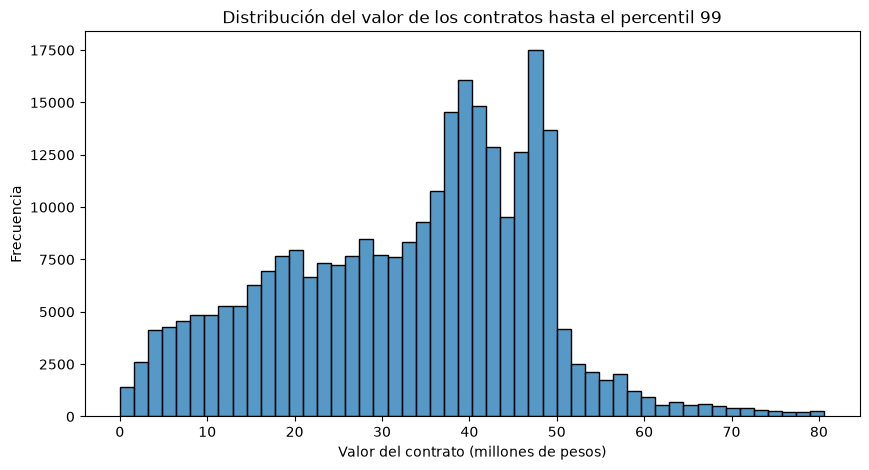

In [19]:
limite_99 = df_analisis["valor_del_contrato"].quantile(0.99)

valores_grafica = (
    df_analisis.loc[
        df_analisis["valor_del_contrato"] <= limite_99,
        "valor_del_contrato"
    ]
    / 1_000_000
)

plt.figure(figsize=(10, 5))

sns.histplot(
    x=valores_grafica,
    bins=50
)

plt.title("Distribución del valor de los contratos hasta el percentil 99")
plt.xlabel("Valor del contrato (millones de pesos)")
plt.ylabel("Frecuencia")
plt.show()

### Diagrama de caja hasta el percentil 99

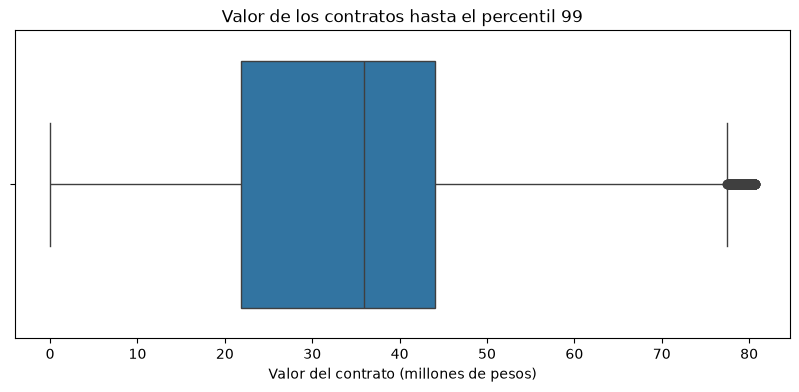

In [20]:
valores_boxplot = (
    df_analisis.loc[
        df_analisis["valor_del_contrato"] <= limite_99,
        "valor_del_contrato"
    ]
    / 1_000_000
)

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=valores_boxplot
)

plt.title("Valor de los contratos hasta el percentil 99")
plt.xlabel("Valor del contrato (millones de pesos)")
plt.show()

### Tamaño de la contratación

In [21]:
gasto_total = df_analisis["valor_del_contrato"].sum()
numero_contratos = df_analisis["id_contrato"].nunique()
numero_personas = df_analisis["documento_proveedor"].nunique()
valor_promedio = df_analisis["valor_del_contrato"].mean()
valor_mediano = df_analisis["valor_del_contrato"].median()

print(f"Valor contratado total analizado: ${gasto_total / 1_000_000_000_000:,.2f} billones")
print(f"Número de contratos: {numero_contratos:,}")
print(f"Número de personas: {numero_personas:,}")
print(f"Valor promedio por contrato: ${valor_promedio / 1_000_000:,.2f} millones")
print(f"Valor mediano por contrato: ${valor_mediano / 1_000_000:,.2f} millones")

Valor contratado total analizado: $9.56 billones
Número de contratos: 281,498
Número de personas: 80,946
Valor promedio por contrato: $33.96 millones
Valor mediano por contrato: $36.09 millones


Después del tratamiento de los registros monetarios extremos,
el análisis comprende aproximadamente 281 mil contratos asociados a cerca de
81 mil personas, por un valor contratado acumulado de $9,56 billones.
El contrato típico se ubica alrededor de $36 millones, por lo que el valor
mediano es una referencia más representativa que el promedio para describir un
contrato individual.

### Preparación de categorías UNSPSC

In [22]:
df_analisis["categoria_unspsc"] = df_analisis["unspsc"].fillna(
    "Sin código UNSPSC"
)

df_analisis["descripcion_unspsc"] = (
    df_analisis["categoria_unspsc"]
    .map(descripciones_unspsc)
    .fillna("Otra categoría")
)

### Gasto por categoría UNSPSC

In [23]:
gasto_unspsc = (
    df_analisis
    .groupby(["categoria_unspsc", "descripcion_unspsc"], dropna=False)
    .agg(
        gasto_total=("valor_del_contrato", "sum"),
        contratos=("id_contrato", "nunique"),
        valor_promedio=("valor_del_contrato", "mean"),
        valor_mediano=("valor_del_contrato", "median")
    )
    .sort_values("gasto_total", ascending=False)
)

gasto_unspsc["porcentaje_gasto"] = (
    gasto_unspsc["gasto_total"]
    / gasto_total
    * 100
)

tabla_unspsc = gasto_unspsc.head(15).copy()

tabla_unspsc["Valor contratado (billones)"] = (
    tabla_unspsc["gasto_total"] / 1_000_000_000_000
)
tabla_unspsc["Promedio (millones)"] = (
    tabla_unspsc["valor_promedio"] / 1_000_000
)
tabla_unspsc["Mediana (millones)"] = (
    tabla_unspsc["valor_mediano"] / 1_000_000
)

tabla_unspsc[
    [
        "Valor contratado (billones)",
        "contratos",
        "Promedio (millones)",
        "Mediana (millones)",
        "porcentaje_gasto"
    ]
].round(2)

,,Valor contratado (billones),contratos,Promedio (millones),Mediana (millones),porcentaje_gasto
categoria_unspsc,descripcion_unspsc,,,,,
80111600,Servicios de personal temporal,5.17,156422,33.02,35.38,54.04
80111601,Asistencia de oficina o administrativa temporal,1.04,32147,32.38,31.94,10.89
86101710,Servicios de formación pedagógica,1.01,29021,34.91,39.39,10.60
80111620,Servicios temporales de recursos humanos,0.44,13312,33.35,34.60,4.64
80111701,Servicios de contratación de personal,0.22,4874,44.78,40.83,2.28
86101700,Servicios de capacitación vocacional no científica,0.22,6469,33.39,37.25,2.26
80111504,Formación o desarrollo laboral,0.21,5842,35.96,40.56,2.20
86101810,Capacitación en habilidades personales,0.11,2886,37.56,40.04,1.13
80161504,Servicios de oficina,0.07,1986,33.15,26.05,0.69


### Categorías UNSPSC con mayor valor contratado

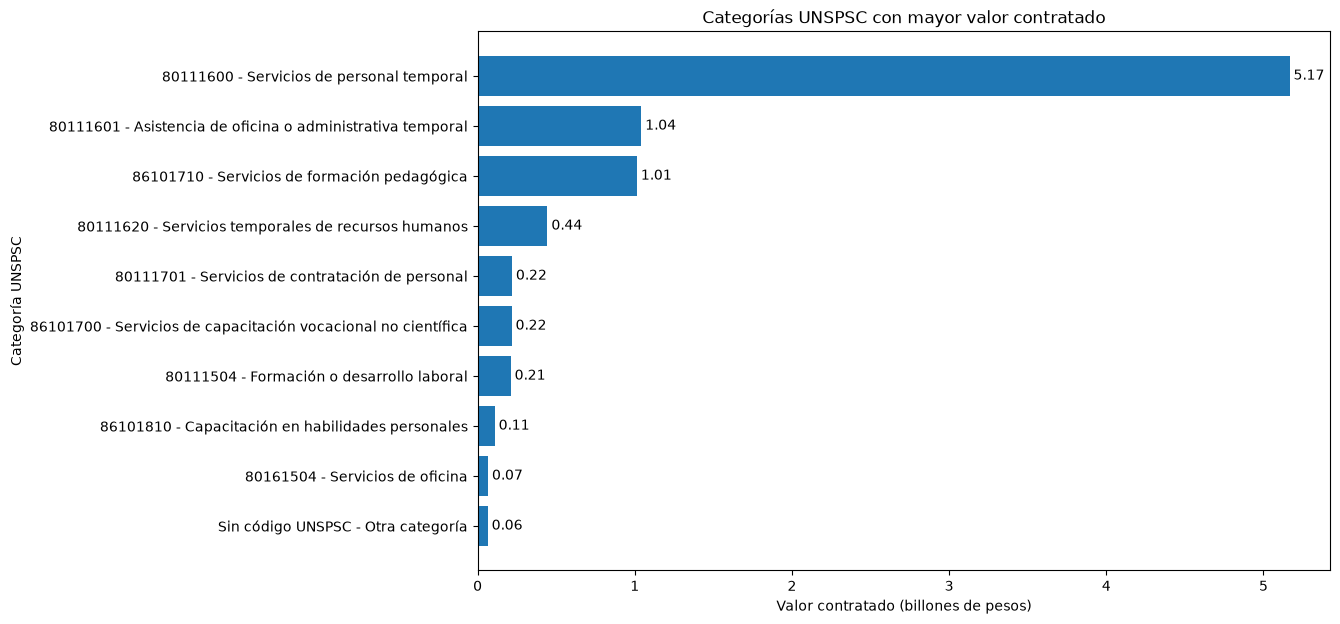

In [24]:
top_unspsc = gasto_unspsc.head(10).reset_index()

top_unspsc["categoria"] = (
    top_unspsc["categoria_unspsc"].astype(str)
    + " - "
    + top_unspsc["descripcion_unspsc"]
)

top_unspsc_grafica = top_unspsc.sort_values("gasto_total")

plt.figure(figsize=(11, 7))

barras = plt.barh(
    top_unspsc_grafica["categoria"],
    top_unspsc_grafica["gasto_total"] / 1_000_000_000_000
)

plt.title("Categorías UNSPSC con mayor valor contratado")
plt.xlabel("Valor contratado (billones de pesos)")
plt.ylabel("Categoría UNSPSC")

for barra, valor in zip(
    barras,
    top_unspsc_grafica["gasto_total"] / 1_000_000_000_000
):
    plt.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f" {valor:.2f}",
        va="center"
    )

plt.show()

### Concentración por UNSPSC

In [25]:
participacion_top5_unspsc = gasto_unspsc.head(5)["porcentaje_gasto"].sum()
participacion_top10_unspsc = gasto_unspsc.head(10)["porcentaje_gasto"].sum()

print(
    f"Participación de las 5 principales categorías UNSPSC: "
    f"{participacion_top5_unspsc:.2f}%"
)
print(
    f"Participación de las 10 principales categorías UNSPSC: "
    f"{participacion_top10_unspsc:.2f}%"
)

Participación de las 5 principales categorías UNSPSC: 82.45%
Participación de las 10 principales categorías UNSPSC: 89.40%


La concentración por tipo de servicio es alta. La categoría
80111600 - Servicios de personal temporal representa cerca del 54,04% del
valor contratado, mientras que las cinco principales categorías concentran
82,45% y las diez primeras 89,40%.

Las categorías UNSPSC corresponden a la clasificación reportada en SECOP II; el
análisis no recodifica manualmente el objeto de cada contrato.

### Número de contratos por UNSPSC

In [26]:
contratos_unspsc = (
    df_analisis
    .groupby(["categoria_unspsc", "descripcion_unspsc"], dropna=False)["id_contrato"]
    .nunique()
    .sort_values(ascending=False)
)

contratos_unspsc.head(15)

categoria_unspsc   descripcion_unspsc                                    
80111600           Servicios de personal temporal                            156422
80111601           Asistencia de oficina o administrativa temporal            32147
86101710           Servicios de formación pedagógica                          29021
80111620           Servicios temporales de recursos humanos                   13312
86101700           Servicios de capacitación vocacional no científica          6469
80111504           Formación o desarrollo laboral                              5842
80111701           Servicios de contratación de personal                       4874
86101810           Capacitación en habilidades personales                      2886
80161504           Servicios de oficina                                        1986
80161500           Servicios de apoyo gerencial                                1551
80111621           Servicios temporales de investigación y desarrollo          1230
Si

### Gasto por regional

In [27]:
gasto_regional = (
    df_analisis
    .groupby("regional")
    .agg(
        gasto_total=("valor_del_contrato", "sum"),
        contratos=("id_contrato", "nunique"),
        personas=("documento_proveedor", "nunique"),
        valor_promedio=("valor_del_contrato", "mean"),
        valor_mediano=("valor_del_contrato", "median")
    )
    .sort_values("gasto_total", ascending=False)
)

gasto_regional["porcentaje_gasto"] = (
    gasto_regional["gasto_total"]
    / gasto_total
    * 100
)

tabla_regional = gasto_regional.head(15).copy()

tabla_regional["Valor contratado (billones)"] = (
    tabla_regional["gasto_total"] / 1_000_000_000_000
)
tabla_regional["Promedio (millones)"] = (
    tabla_regional["valor_promedio"] / 1_000_000
)
tabla_regional["Mediana (millones)"] = (
    tabla_regional["valor_mediano"] / 1_000_000
)

tabla_regional[
    [
        "Valor contratado (billones)",
        "contratos",
        "personas",
        "Promedio (millones)",
        "Mediana (millones)",
        "porcentaje_gasto"
    ]
].round(2)

,Valor contratado (billones),contratos,personas,Promedio (millones),Mediana (millones),porcentaje_gasto
regional,,,,,,
Distrito Capital de Bogotá,1.42,43244,12980,32.86,36.06,14.86
Antioquia,1.11,31376,9487,35.48,39.39,11.64
Valle del Cauca,0.63,19392,5625,32.31,35.11,6.55
Nivel Central,0.59,10364,3766,57.10,56.64,6.19
Atlántico,0.52,17288,4468,29.87,30.36,5.40
Santander,0.50,15819,5195,31.53,34.40,5.22
Cundinamarca,0.40,11783,4327,33.86,38.22,4.17
Tolima,0.33,9077,2693,36.38,39.09,3.45
Bolívar,0.30,9132,2432,33.25,37.27,3.18


### Regionales con mayor valor contratado

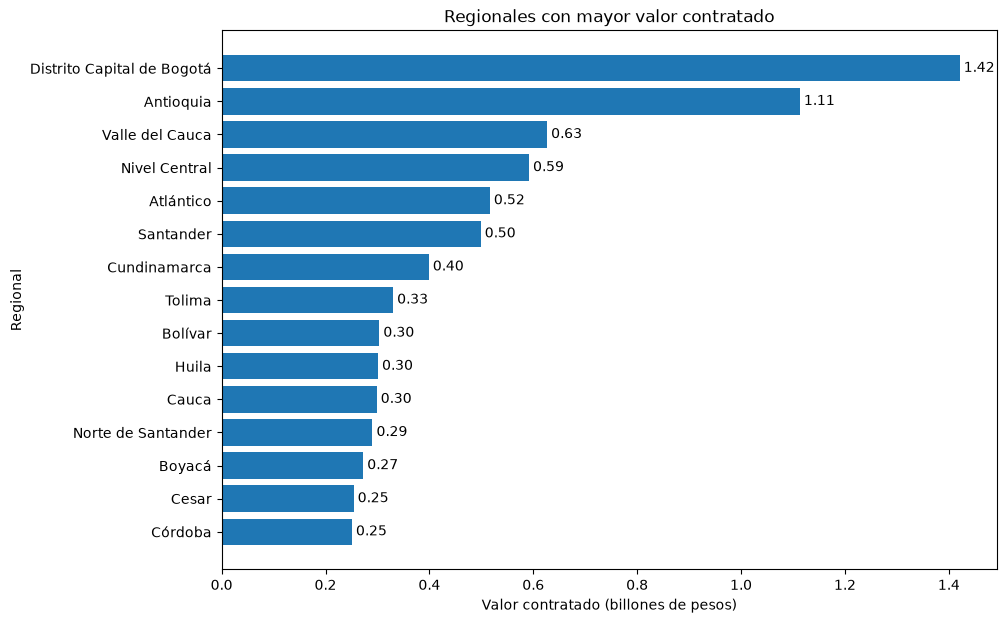

In [28]:
top_regionales = gasto_regional.head(15).sort_values("gasto_total")

plt.figure(figsize=(10, 7))

barras = plt.barh(
    top_regionales.index,
    top_regionales["gasto_total"] / 1_000_000_000_000
)

plt.title("Regionales con mayor valor contratado")
plt.xlabel("Valor contratado (billones de pesos)")
plt.ylabel("Regional")

for barra, valor in zip(
    barras,
    top_regionales["gasto_total"] / 1_000_000_000_000
):
    plt.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f" {valor:.2f}",
        va="center"
    )

plt.show()

### Participación del valor contratado por regional

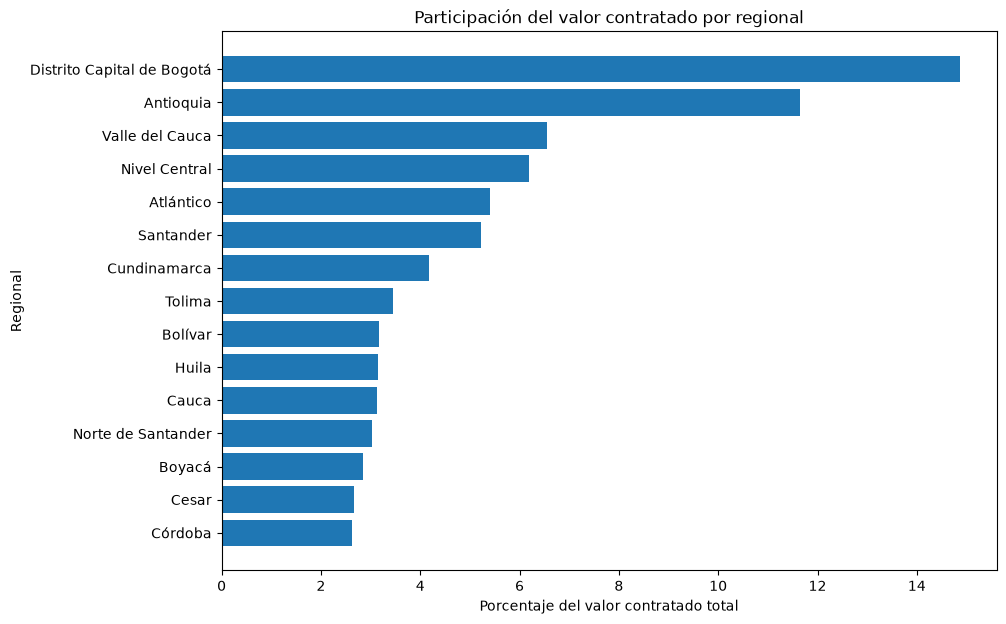

In [29]:
top_regionales_pct = gasto_regional.head(15).sort_values("porcentaje_gasto")

plt.figure(figsize=(10, 7))

plt.barh(
    top_regionales_pct.index,
    top_regionales_pct["porcentaje_gasto"]
)

plt.title("Participación del valor contratado por regional")
plt.xlabel("Porcentaje del valor contratado total")
plt.ylabel("Regional")
plt.show()

### Concentración regional

In [30]:
participacion_top5_regiones = gasto_regional.head(5)["porcentaje_gasto"].sum()
participacion_top10_regiones = gasto_regional.head(10)["porcentaje_gasto"].sum()

print(
    f"Participación de las 5 principales regionales: "
    f"{participacion_top5_regiones:.2f}%"
)
print(
    f"Participación de las 10 principales regionales: "
    f"{participacion_top10_regiones:.2f}%"
)

Participación de las 5 principales regionales: 44.66%
Participación de las 10 principales regionales: 63.83%


Interpretación. La concentración geográfica es menor que la concentración por
UNSPSC. Distrito Capital de Bogotá representa aproximadamente 14,86% del
valor contratado y Antioquia 11,64%. Las cinco principales regionales suman
44,66% y las diez principales 63,83% del total analizado.

### Valor de los contratos por regional

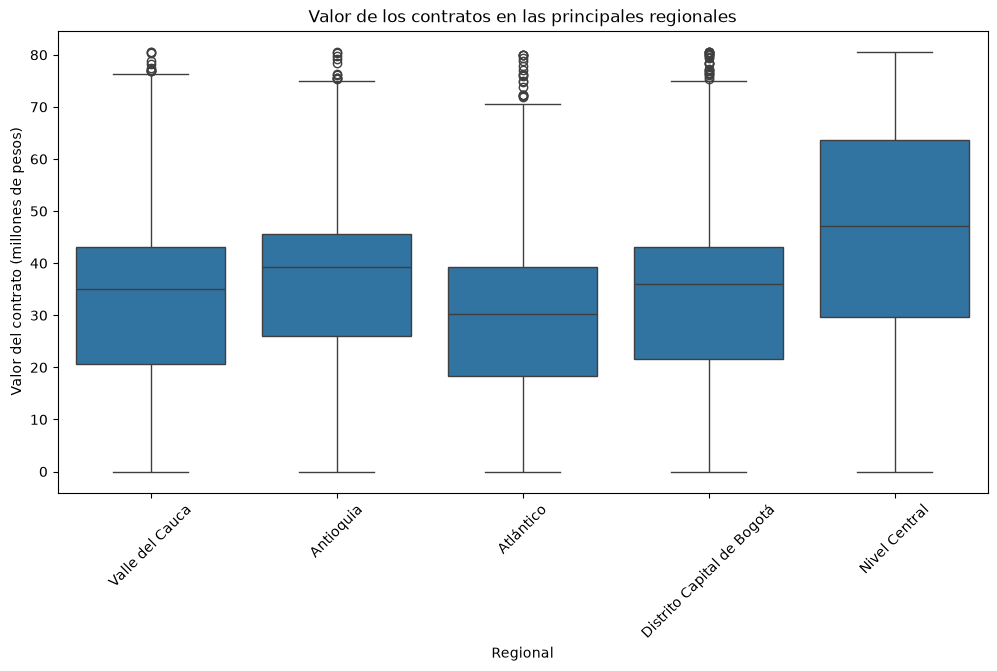

In [31]:
top_5_regionales = gasto_regional.head(5).index

df_top_regionales = df_analisis[
    df_analisis["regional"].isin(top_5_regionales)
].copy()

df_top_regionales_grafica = df_top_regionales[
    df_top_regionales["valor_del_contrato"] <= limite_99
].copy()

df_top_regionales_grafica["valor_millones"] = (
    df_top_regionales_grafica["valor_del_contrato"] / 1_000_000
)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top_regionales_grafica,
    x="regional",
    y="valor_millones"
)

plt.title("Valor de los contratos en las principales regionales")
plt.xlabel("Regional")
plt.ylabel("Valor del contrato (millones de pesos)")
plt.xticks(rotation=45)
plt.show()

El diagrama de caja compara la distribución del valor de los contratos entre las
cinco regionales con mayor valor contratado. Para facilitar la visualización se limita
el gráfico al percentil 99; los demás registros válidos siguen incluidos en los cálculos.

### Prueba de Kruskal-Wallis

In [32]:
grupos_regionales = [
    df_analisis.loc[
        df_analisis["regional"] == regional,
        "valor_del_contrato"
    ].dropna()
    for regional in top_5_regionales
]

estadistico, p_valor = kruskal(*grupos_regionales)

print(f"Estadístico de Kruskal-Wallis: {estadistico:.4f}")
print(f"p-valor: {p_valor:.6f}")

Estadístico de Kruskal-Wallis: 9224.7713
p-valor: 0.000000


La prueba de Kruskal-Wallis compara la distribución del valor de los contratos
entre las cinco regionales con mayor valor contratado.

En la ejecución realizada se obtuvo un p-valor menor a 0,001, por lo que se
rechaza la hipótesis de igualdad de distribuciones. Existe evidencia de que el
valor de los contratos no se distribuye de la misma manera en todas las cinco
regionales principales.

### Resumen de resultados

In [33]:
resumen_resultados = pd.DataFrame({
    "Indicador": [
        "Valor contratado total analizado",
        "Número de contratos",
        "Número de personas",
        "Valor promedio",
        "Valor mediano",
        "Participación top 5 UNSPSC",
        "Participación top 10 UNSPSC",
        "Participación top 5 regionales",
        "Participación top 10 regionales",
        "Registros monetarios extremos excluidos"
    ],
    "Resultado": [
        f"${gasto_total / 1_000_000_000_000:,.2f} billones",
        f"{numero_contratos:,}",
        f"{numero_personas:,}",
        f"${valor_promedio / 1_000_000:,.2f} millones",
        f"${valor_mediano / 1_000_000:,.2f} millones",
        f"{participacion_top5_unspsc:.2f}%",
        f"{participacion_top10_unspsc:.2f}%",
        f"{participacion_top5_regiones:.2f}%",
        f"{participacion_top10_regiones:.2f}%",
        f"{len(df_valores_extremos):,}"
    ]
})

resumen_resultados

,Indicador,Resultado
0,Valor contratado total analizado,$9.56 billones
1,Número de contratos,"281,498"
2,Número de personas,"80,946"
3,Valor promedio,$33.96 millones
4,Valor mediano,$36.09 millones
5,Participación top 5 UNSPSC,82.45%
6,Participación top 10 UNSPSC,89.40%
7,Participación top 5 regionales,44.66%
8,Participación top 10 regionales,63.83%
9,Registros monetarios extremos excluidos,137


### Principales resultados para responder la pregunta

In [34]:
principal_unspsc = gasto_unspsc.reset_index().iloc[0]
principal_regional = gasto_regional.reset_index().iloc[0]

print(
    f"La principal categoría UNSPSC es "
    f"{principal_unspsc['categoria_unspsc']} - "
    f"{principal_unspsc['descripcion_unspsc']}, "
    f"con {principal_unspsc['porcentaje_gasto']:.2f}% del valor contratado."
)

print(
    f"La regional con mayor valor contratado es "
    f"{principal_regional['regional']}, "
    f"con {principal_regional['porcentaje_gasto']:.2f}% del total."
)

print(
    f"Las cinco principales categorías UNSPSC concentran "
    f"{participacion_top5_unspsc:.2f}% del valor contratado."
)

print(
    f"Las cinco principales regionales concentran "
    f"{participacion_top5_regiones:.2f}% del valor contratado."
)

La principal categoría UNSPSC es 80111600 - Servicios de personal temporal, con 54.04% del valor contratado.
La regional con mayor valor contratado es Distrito Capital de Bogotá, con 14.86% del total.
Las cinco principales categorías UNSPSC concentran 82.45% del valor contratado.
Las cinco principales regionales concentran 44.66% del valor contratado.


### Conclusiones

Para el periodo disponible en los datos, entre octubre de 2017 y agosto de 2026,
la contratación de prestación de servicios con personas naturales representa
aproximadamente **85,85%** de los registros del SENA analizados.

Después de separar **137 registros monetarios extremos**, menos del **0,05%** de
los contratos individuales, pero responsables de prácticamente todo el valor
bruto antes del tratamiento, se analizaron **281.498 contratos** asociados a
**80.946 personas**. El valor contratado acumulado es de aproximadamente
**$9,56 billones**, con un valor mediano por contrato de **$36,09 millones**.

El valor contratado está **fuertemente concentrado por categoría UNSPSC**:
80111600 - Servicios de personal temporal explica cerca del **54,04%** del
total; las cinco categorías principales acumulan **82,45%** y las diez primeras
**89,40%**. Esto muestra que la mayor parte del valor se concentra en un conjunto
pequeño de tipos de servicio.

La concentración regional es más distribuida. **Distrito Capital de Bogotá**
lidera con **14,86%**, seguido de **Antioquia** con **11,64%**. Las cinco
principales regionales concentran **44,66%** del valor contratado y las diez
primeras **63,83%**.

Finalmente, la prueba de Kruskal-Wallis obtuvo un **p-valor menor a 0,001**,
lo que aporta evidencia de diferencias en la distribución del valor contractual
entre las cinco regionales con mayor valor contratado.

En conjunto, la pregunta de negocio muestra que el SENA maneja un volumen
considerable de contratación de servicios con personas naturales y que su valor
se concentra mucho más por **tipo de servicio** que por **regional**.